# Анализ характера влияния возраста на дефолт по кредиту с использованием KAN

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve
from sklearn.metrics import mean_squared_error, roc_curve

import torch
import torch.nn as nn
import torch.optim as optim
from kan import *

import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

# Не используются
# from imblearn.over_sampling import SMOTE
# from imblearn.combine import SMOTEENN
# from imblearn.under_sampling import EditedNearestNeighbours


# Импорт датасета

В качестве датасета выбраны данные данные соревнования Home Credit Default Risk. Размер обучающей выборки, как можно увидеть ниже, составляет 307511 записей.

In [2]:
def download_home_credit_data():

    api = KaggleApi()
    api.authenticate()
    
    competition = 'home-credit-default-risk'
    
    api.competition_download_files(competition)
    
    zip_file_name = f'{competition}.zip'
    
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.')
    
    
# Вызов функции для скачивания
# download_home_credit_data()

train_data = pd.read_csv('application_train.csv')
print(f"Размер данных: {train_data.shape}")

Размер данных: (307511, 122)


# Фильтрация данных

В качестве значимых признаков был выделен возраст и ряд признаков без пропусков данных

In [3]:
def load_and_prepare_data(train_data = None):

    if train_data is None:
        train_data = pd.read_csv('application_train.csv')
    
    # Перевод дней в года
    train_data['AGE'] = -train_data['DAYS_BIRTH'] / 365.25
    train_data['AGE'] = train_data['AGE'].astype(int)
    
    # Выбор ключевых признаков для анализа
    features = [
        'AGE',               # возраст
        'AMT_INCOME_TOTAL',  # общий доход
        'AMT_CREDIT',        # сумма кредита
        'AMT_ANNUITY',       # сумма аннуитета
        'DAYS_EMPLOYED',     # стаж работы в днях
        'CNT_CHILDREN',      # количество детей
        'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'  # внешние скоринговые баллы
    ]
    
    # Целевая переменная: TARGET (1 - проблемы с платежами, 0 - нет проблем)
    target = 'TARGET'
    
    # Удаление пропущенных значений
    data = train_data[features + [target]].dropna()
    
    return data, features, target

data, features, target = load_and_prepare_data()

In [4]:
def missing_values_table(df):
    
        # Всего недостает
        mis_val = df.isnull().sum()
        
        # Процент недостающих данных
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Таблица с результатами
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Переименование столбцов
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Сортировка про процентажу
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        print ("В выбранном датафрейме " + str(df.shape[1]) + " столбцов.\n"      
            "Всего " + str(mis_val_table_ren_columns.shape[0]) +
              " столбцов с неполными данными.")
        
        # Возврат таблицы с данными
        return mis_val_table_ren_columns

In [5]:
missing_values = missing_values_table(train_data)
missing_values.head(10)

В выбранном датафрейме 122 столбцов.
Всего 67 столбцов с неполными данными.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


# Первичный анализ данных

In [6]:
print(f"Размер датасета после удаления неполных записей: {data.shape}")
print(f"Распределение целевой переменной:\n{data[target].value_counts(normalize=True)}")

Размер датасета после удаления неполных записей: (109582, 10)
Распределение целевой переменной:
TARGET
0    0.927014
1    0.072986
Name: proportion, dtype: float64


Можно заметить, что наблюдается дисбаланс выходной переменной. 93% людей не имеют проблем при возвращении кредита. Данную проблему можно решить с использованием SMOTE.

In [7]:
data.head()

,AGE,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_EMPLOYED,CNT_CHILDREN,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,TARGET
0,25,202500.000,406597.5,24700.5,-637,0,0.083037,0.262949,0.139376,1
6,37,171000.000,1560726.0,41301.0,-3130,1,0.774761,0.724000,0.492060,0
8,55,112500.000,1019610.0,33826.5,365243,0,0.587334,0.205747,0.751724,0
10,27,112500.000,652500.0,21177.0,-679,1,0.319760,0.651862,0.363945,0
11,55,38419.155,148365.0,10678.5,365243,0,0.722044,0.555183,0.652897,0


In [8]:
correlations = data.corr()['TARGET'].sort_values()
print('Корреляция признаков: \n', correlations)

Корреляция признаков: 
 EXT_SOURCE_3       -0.173472
EXT_SOURCE_1       -0.154757
EXT_SOURCE_2       -0.144827
AGE                -0.066010
AMT_CREDIT         -0.029245
DAYS_EMPLOYED      -0.027075
AMT_ANNUITY        -0.009171
AMT_INCOME_TOTAL    0.004591
CNT_CHILDREN        0.009776
TARGET              1.000000
Name: TARGET, dtype: float64


Таким образом, все данные слабо коррелируют с таргетом (кроме самого таргета, который, понятно, равен сам себе). Однако из данных выделяются возраст и внешние оценки кредитного риска.

Визуализация возрастов клиентов

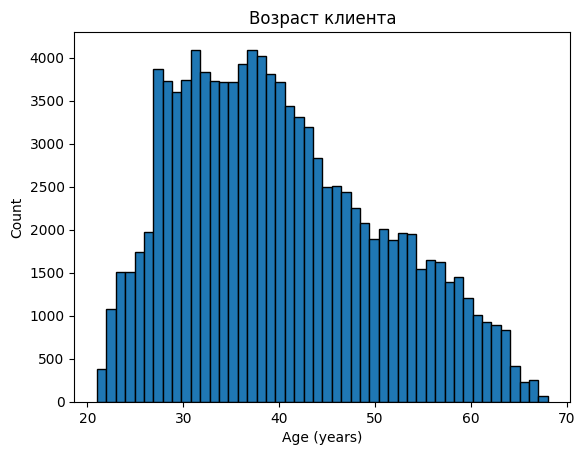

In [9]:
plt.hist(data['AGE'], edgecolor = 'k', bins = 48)
plt.title('Возраст клиента'); plt.xlabel('Age (years)'); plt.ylabel('Count');

Text(0.5, 1.0, 'Распределение возраста')

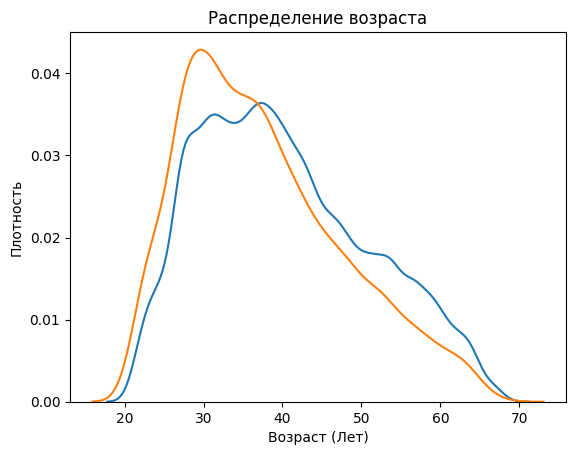

In [10]:
# KDE займов, выплаченных вовремя (распределение ядерной плотности, раскрашенный в цвета целевого признака)
sns.kdeplot(data.loc[data['TARGET'] == 0, 'AGE'], label = 'target == 0')
# KDE проблемных займов
sns.kdeplot(data.loc[data['TARGET'] == 1, 'AGE'], label = 'target == 1')

plt.xlabel('Возраст (Лет)'); plt.ylabel('Плотность'); plt.title('Распределение возраста')

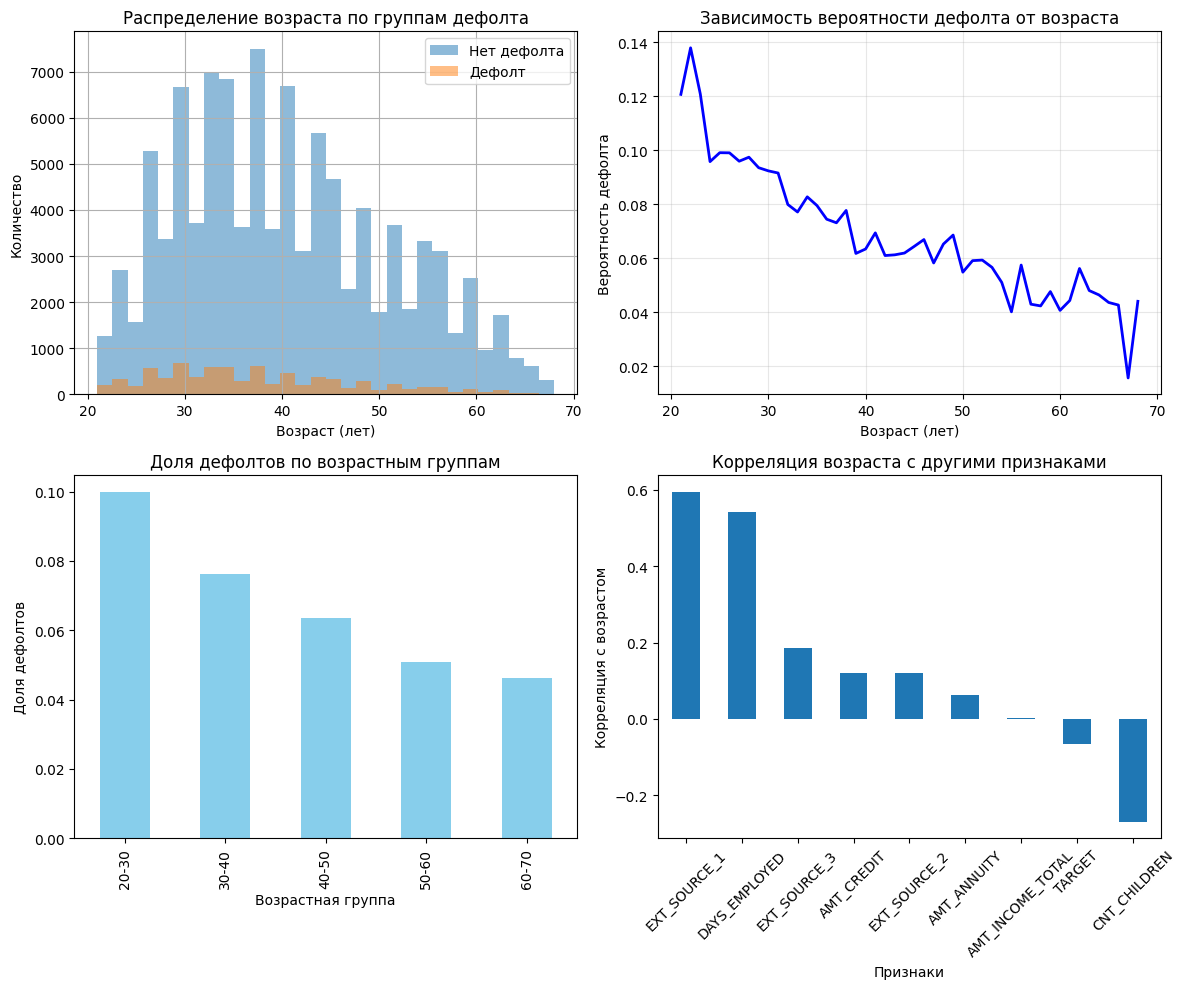

In [11]:
# Визуализация влияния возраста на дефолт
def visualize_age_impact(data, target):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10)) # , layout='constrained'
    
    # Распределение возраста в зависимости от дефолта
    ax1 = axes[0,0]
    data[data[target] == 0]['AGE'].hist(alpha=0.5, bins=30, label='Нет дефолта', ax=ax1)
    data[data[target] == 1]['AGE'].hist(alpha=0.5, bins=30, label='Дефолт', ax=ax1)
    ax1.set_xlabel('Возраст (лет)')
    ax1.set_ylabel('Количество')
    ax1.set_title('Распределение возраста по группам дефолта')
    ax1.legend()
    
    # Средняя вероятность дефолта по возрасту
    ax2 = axes[0,1]
    age_default_rate = data.groupby('AGE')[target].mean().reset_index()
    ax2.plot(age_default_rate['AGE'], age_default_rate[target], 'b-', linewidth=2)
    ax2.set_xlabel('Возраст (лет)')
    ax2.set_ylabel('Вероятность дефолта')
    ax2.set_title('Зависимость вероятности дефолта от возраста')
    ax2.grid(True, alpha=0.3)
    
    # Биннинг возраста и анализ дефолтов
    data1 = data.copy()
    ax3 = axes[1,0]
    data1['AGE_GROUP'] = pd.cut(data1['AGE'], 
                               bins=[20, 30, 40, 50, 60, 70], 
                               labels=['20-30', '30-40', '40-50', '50-60', '60-70'])
    age_group_rate = data1.groupby('AGE_GROUP', observed=True)[target].mean()
    age_group_rate.plot(kind='bar', ax=ax3, color='skyblue')
    ax3.set_xlabel('Возрастная группа')
    ax3.set_ylabel('Доля дефолтов')
    ax3.set_title('Доля дефолтов по возрастным группам')
    
    # Корреляция возраста с другими признаками
    ax4 = axes[1, 1]
    corr_matrix = data.corr()
    age_corr = corr_matrix['AGE'].sort_values(ascending=False)
    age_corr.drop('AGE').plot(kind='bar', ax=ax4)
    ax4.set_xlabel('Признаки')
    ax4.set_ylabel('Корреляция с возрастом')
    ax4.set_title('Корреляция возраста с другими признаками')
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return data
    
data1 = visualize_age_impact(data, target)

# Нормализация и подготовка данных для обучения

20% данных остаётся на тестирование результатов

In [12]:
def prepare_kan_data(data, features, target):

    # Разделение на признаки и целевую переменную
    X = data[features].values
    y = data[target].values

    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)  
    
    #smote_enn = SMOTEENN(
    #    smote=SMOTE(sampling_strategy=0.2),  
    #    enn=EditedNearestNeighbours(sampling_strategy='all')
    #)
    
    #X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)
        
    #print(f"Размеры ПОСЛЕ SMOTE: X_train{X_train_resampled.shape}, y_train{y_train_resampled.shape}")
    #print(f"Распределение классов после SMOTE: {np.bincount(y_train_resampled.astype(int))}")
        
    #X_train_final, y_train_final = X_train_resampled, y_train_resampled

    X_train_final, y_train_final = X_train_scaled, y_train
    
    print(f"\nФинальные размеры:")
    print(f"Обучающая выборка: {X_train_final.shape}")
    print(f"Тестовая выборка: {X_test_scaled.shape}")
    
    return X_train_final, X_test_scaled, y_train_final, y_test, scaler, features
    
# 3. Подготовка данных для KAN
X_train, X_test, y_train, y_test, scaler, features = prepare_kan_data(
    data, features, target
)


Финальные размеры:
Обучающая выборка: (87665, 9)
Тестовая выборка: (21917, 9)


# Построение модели

Финальная структура модели - 9 входных слоёв под признаки, 10 нейронов в первом скрытом слоё, 5 нейронов во втором скрытом слоё, один выходной нейрон. В качестве основных гиперпараметров - grid равен трём, k равен 3. На обучение отводится 150 шагов.

Используется устройство: cuda
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.49e-01 | test_loss: 2.51e-01 | reg: 1.61e-01 | : 100%|█| 150/150 [05:03<00:00,  2.02


saving model version 0.1
Обучение завершено успешно!


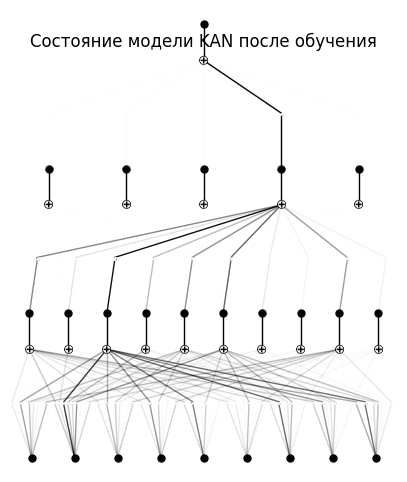

Оптимальный порог: 0.520
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     20317
           1       0.16      0.65      0.26      1600

    accuracy                           0.72     21917
   macro avg       0.56      0.69      0.54     21917
weighted avg       0.91      0.72      0.79     21917

ROC-AUC: 0.7499


In [13]:
def analyze_with_kan_stable(X_train, X_test, y_train, y_test, features):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используется устройство: {device}")

    # Создание тензоров и перенос на GPU
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1).to(device)

    # СОЗДАНИЕ МОДЕЛИ
    model = KAN(width=[len(features), 10, 5, 1],  
                grid=3,                           
                k=3,                              
                seed=1,
                device=device)

    dataset = {
        'train_input': X_train_tensor,
        'train_label': y_train_tensor,
        'test_input': X_test_tensor,
        'test_label': y_test_tensor
    }

    # ОБУЧЕНИЕ
    try:
        results = model.fit(dataset=dataset,
                           steps=150,         # Сначала меньше шагов
                           lr=1,              # Меньшая скорость обучения
                           lamb=0.01,         # Увеличиваем общую регуляризацию
                           lamb_l1=0.01,      # L1 регуляризация
                           lamb_entropy=0.2,  # СУЩЕСТВЕННО уменьшаем энтропийную регуляризацию
                           batch=-1,
                           stop_grid_update_step=149  # Ранняя остановка обновления сетки
                           )       
        print("Обучение завершено успешно!")

    except Exception as e:
        print(f"\n Во время обучения произошла ошибка: {type(e).__name__}: {e}")
        return None, None, None

    # ВИЗУАЛИЗАЦИЯ ПРОГРЕССА 
    model.plot()
    plt.title("Состояние модели KAN после обучения")
    plt.show()


    # ПРЕДСКАЗАНИЕ И ОЦЕНКА
    with torch.no_grad():
        model.eval()
        y_pred = model(X_test_tensor)
        y_pred_proba = torch.sigmoid(y_pred).cpu().numpy()


    fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
    optimal_idx = np.argmax(tpr - fpr)  # индекс максимальной разницы
    optimal_threshold_roc = thresholds_roc[optimal_idx]
    
    print(f"Оптимальный порог: {optimal_threshold_roc:.3f}")
    
    y_pred_optimal = (y_pred_proba >= optimal_threshold_roc).astype(int)
    print(classification_report(y_test, y_pred_optimal))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    return model, y_pred_proba, results
   
model, y_pred_proba, results = analyze_with_kan_stable(
    X_train, X_test, y_train, y_test, features
)

# Представление результатов


Точность модели составляет 72-74%, ROC-AUC = 75%. Модель обладает значимой предсказательной силой, но дисбаланс классов портит общую картину.

In [26]:
model.auto_symbolic()

fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,0,2) with 0, r2=0.0, c=0
fixing (0,0,3) with 0, r2=0.0, c=0
fixing (0,0,4) with 0, r2=0.0, c=0
fixing (0,0,5) with 0, r2=0.0, c=0
fixing (0,0,6) with 0, r2=0.0, c=0
fixing (0,0,7) with 0, r2=0.0, c=0
fixing (0,0,8) with 0, r2=0.0, c=0
fixing (0,0,9) with 0, r2=0.0, c=0
fixing (0,1,0) with 0, r2=0.0, c=0
fixing (0,1,1) with 0, r2=0.0, c=0
fixing (0,1,2) with 0, r2=0.0, c=0
fixing (0,1,3) with 0, r2=0.0, c=0
fixing (0,1,4) with 0, r2=0.0, c=0
fixing (0,1,5) with 0, r2=0.0, c=0
fixing (0,1,6) with 0, r2=0.0, c=0
fixing (0,1,7) with 0, r2=0.0, c=0
fixing (0,1,8) with 0, r2=0.0, c=0
fixing (0,1,9) with 0, r2=0.0, c=0
fixing (0,2,0) with 0, r2=0.0, c=0
fixing (0,2,1) with 0, r2=0.0, c=0
fixing (0,2,2) with 0, r2=0.0, c=0
fixing (0,2,3) with 0, r2=0.0, c=0
fixing (0,2,4) with 0, r2=0.0, c=0
fixing (0,2,5) with 0, r2=0.0, c=0
fixing (0,2,6) with 0, r2=0.0, c=0
fixing (0,2,7) with 0, r2=0.0, c=0
fixing (0,2,8) with 

In [14]:
model.plot(beta=1, scale=10,  varscale=5)
plt.show()


5. ДЕТАЛЬНЫЙ АНАЛИЗ ВЛИЯНИЯ ПРИЗНАКОВ


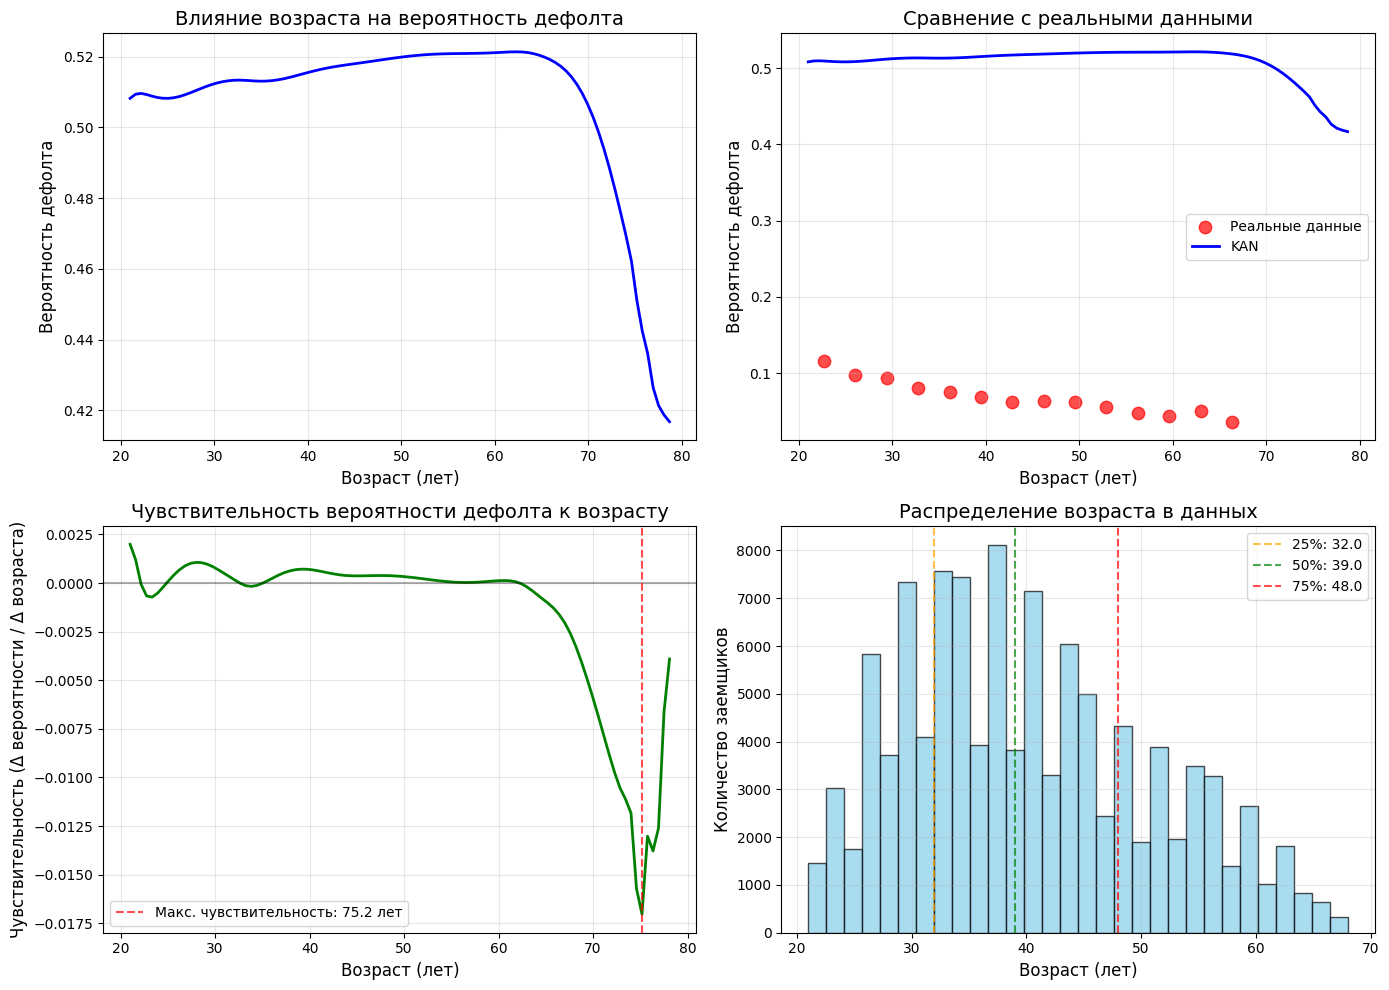


Критические возрастные точки:
  • Минимальный риск дефолта: 78.7 лет (вероятность: 0.4167)
  • Максимальный риск дефолта: 62.4 лет (вероятность: 0.5214)
  • Порог высокого риска (вероятность > 0.5): 21.0 лет

=== АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ===


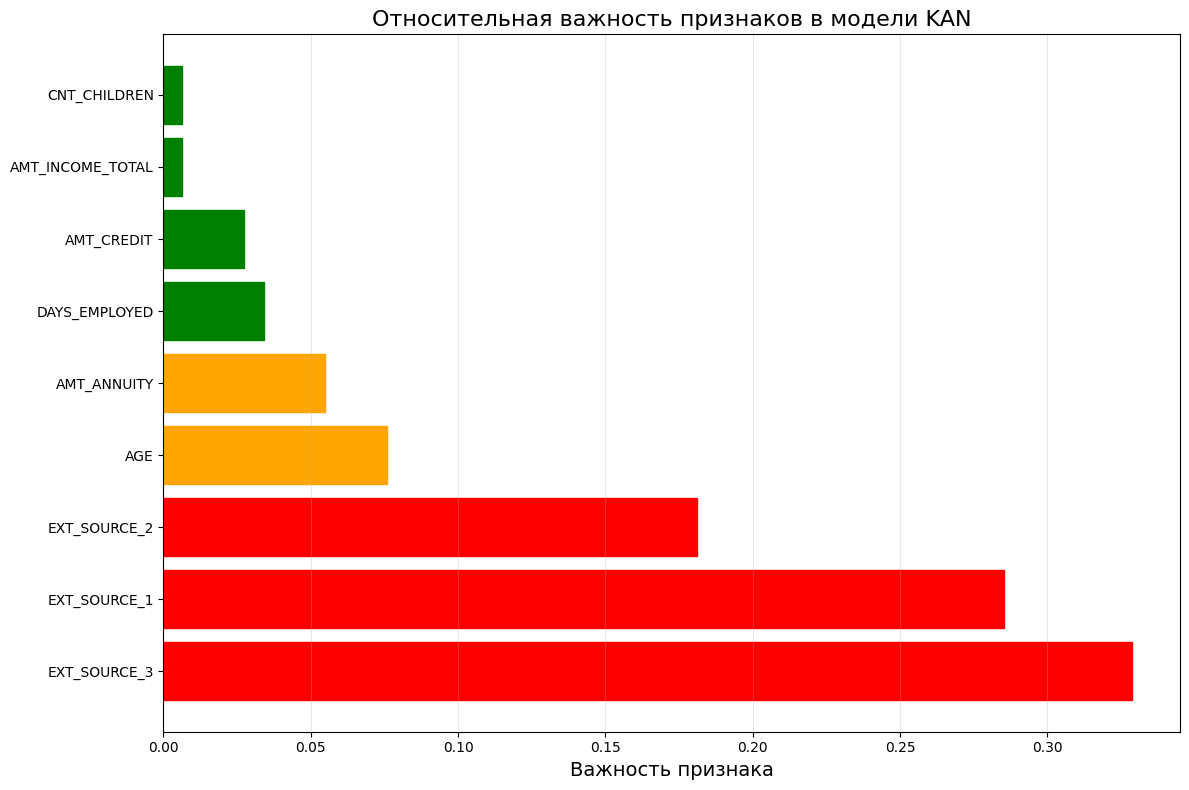


Топ-5 наиболее важных признаков:
  EXT_SOURCE_3: 0.3286
  EXT_SOURCE_1: 0.2854
  EXT_SOURCE_2: 0.1809
  AGE: 0.0760
  AMT_ANNUITY: 0.0548


In [25]:
def analyze_feature_influence(model, X_test_scaled, y_test, features, scaler, original_data=None):

    device = next(model.parameters()).device if hasattr(model, 'parameters') else torch.device('cpu')

    # Преобразуем данные в тензоры и переносим на GPU
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    
    if 'AGE' in features:
        age_idx = features.index('AGE')
        
        # Создаем синтетические данные для анализа
        n_points = 100
        
        # Вариант A: Анализ в нормализованном пространстве
        # Создаем базовый образец (средние значения всех признаков)
        base_sample = np.median(X_test_scaled, axis=0, keepdims=True).repeat(n_points, axis=0)
        
        # Варируем возраст в пределах нормализованного диапазона
        age_range_normalized = np.linspace(
            X_test_scaled[:, age_idx].min(),
            X_test_scaled[:, age_idx].max() + 1,
            n_points
        )
        
        # Заменяем значения возраста в базовом образце
        synthetic_samples = base_sample.copy()
        synthetic_samples[:, age_idx] = age_range_normalized
        
        # Преобразуем в тензор и переносим на устройство
        synthetic_tensor = torch.tensor(synthetic_samples, dtype=torch.float32).to(device)
        
        # Получаем предсказания модели
        with torch.no_grad():
            model.eval()
            predictions = model(synthetic_tensor)
            age_effects = torch.sigmoid(predictions).cpu().numpy().flatten()
        
        # Преобразуем возраст обратно в исходный масштаб для интерпретации
        # Для этого создаем фиктивный датасет и применяем обратное преобразование
        dummy_data = np.zeros((n_points, len(features)))
        dummy_data[:, age_idx] = age_range_normalized
        
        # Применяем обратное преобразование для возраста
        if hasattr(scaler, 'inverse_transform'):
            dummy_original = scaler.inverse_transform(dummy_data)
            age_range_original = dummy_original[:, age_idx]

        # Визуализация влияния возраста
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # График 1: Влияние возраста на вероятность дефолта
        ax1 = axes[0, 0]
        ax1.plot(age_range_original, age_effects, 'b-', linewidth=2)
        ax1.set_xlabel('Возраст (лет)', fontsize=12)
        ax1.set_ylabel('Вероятность дефолта', fontsize=12)
        ax1.set_title('Влияние возраста на вероятность дефолта', fontsize=14)
        ax1.grid(True, alpha=0.3)
        
        # Добавляем квантили для интерпретации
        if original_data is not None and 'AGE' in original_data.columns:
            age_q25 = original_data['AGE'].quantile(0.25)
            age_q50 = original_data['AGE'].quantile(0.50)
            age_q75 = original_data['AGE'].quantile(0.75)
            
        
        # График 2: Сравнение с реальными данными
        ax2 = axes[0, 1]
        
        # Группируем реальные данные по возрасту (в исходном масштабе)
        if original_data is not None and 'AGE' in original_data.columns and 'TARGET' in original_data.columns:
            # Биннинг возраста для реальных данных
            age_bins = np.linspace(original_data['AGE'].min(), 
                                 original_data['AGE'].max(), 15)
            original_data['AGE_GROUP'] = pd.cut(original_data['AGE'], age_bins)
            
            # Средняя вероятность дефолта по группам возраста
            real_age_effect = original_data.groupby('AGE_GROUP', observed=True)['TARGET'].mean()
            bin_centers = [(bin.left + bin.right)/2 for bin in real_age_effect.index]
            
            ax2.scatter(bin_centers, real_age_effect.values, alpha=0.7, 
                       color='red', s=80, label='Реальные данные')
            ax2.plot(age_range_original, age_effects, 'b-', linewidth=2, 
                    label='KAN')
            ax2.set_xlabel('Возраст (лет)', fontsize=12)
            ax2.set_ylabel('Вероятность дефолта', fontsize=12)
            ax2.set_title('Сравнение с реальными данными', fontsize=14)
            ax2.legend()
            ax2.grid(True, alpha=0.3)
        
        # График 3: Производная (чувствительность к возрасту)
        ax3 = axes[1, 0]
        if len(age_effects) > 1:
            # Вычисляем производную (чувствительность вероятности к изменению возраста)
            derivative = np.gradient(age_effects, age_range_original)
            ax3.plot(age_range_original[:-1], derivative[:-1], 'g-', linewidth=2)
            ax3.axhline(y=0, color='k', linestyle='-', alpha=0.3)
            ax3.set_xlabel('Возраст (лет)', fontsize=12)
            ax3.set_ylabel('Чувствительность (Δ вероятности / Δ возраста)', fontsize=12)
            ax3.set_title('Чувствительность вероятности дефолта к возрасту', fontsize=14)
            ax3.grid(True, alpha=0.3)
            
            # Находим возраст с максимальной чувствительностью
            max_sens_idx = np.argmax(np.abs(derivative[:-1]))
            max_sens_age = age_range_original[max_sens_idx]
            max_sens_value = derivative[max_sens_idx]
            ax3.axvline(x=max_sens_age, color='r', linestyle='--', alpha=0.7,
                       label=f'Макс. чувствительность: {max_sens_age:.1f} лет')
            ax3.legend()
        
        # График 4: Распределение возраста в тестовой выборке
        ax4 = axes[1, 1]
        if original_data is not None and 'AGE' in original_data.columns:
            # Гистограмма распределения возраста
            ax4.hist(original_data['AGE'], bins=30, alpha=0.7, 
                    color='skyblue', edgecolor='black')
            ax4.set_xlabel('Возраст (лет)', fontsize=12)
            ax4.set_ylabel('Количество заемщиков', fontsize=12)
            ax4.set_title('Распределение возраста в данных', fontsize=14)
            ax4.grid(True, alpha=0.3)
            
            # Добавляем вертикальные линии для квантилей
            if 'age_q25' in locals():
                ax4.axvline(x=age_q25, color='orange', linestyle='--', 
                           alpha=0.7, label=f'25%: {age_q25:.1f}')
                ax4.axvline(x=age_q50, color='green', linestyle='--', 
                           alpha=0.7, label=f'50%: {age_q50:.1f}')
                ax4.axvline(x=age_q75, color='red', linestyle='--', 
                           alpha=0.7, label=f'75%: {age_q75:.1f}')
                ax4.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Анализ критических возрастных точек
        print("\nКритические возрастные точки:")
        
        # Находим возраст, где вероятность дефолта минимальна
        min_prob_age = age_range_original[np.argmin(age_effects)]
        min_prob_value = np.min(age_effects)
        print(f"  • Минимальный риск дефолта: {min_prob_age:.1f} лет (вероятность: {min_prob_value:.4f})")
        
        # Находим возраст, где вероятность дефолта максимальна
        max_prob_age = age_range_original[np.argmax(age_effects)]
        max_prob_value = np.max(age_effects)
        print(f"  • Максимальный риск дефолта: {max_prob_age:.1f} лет (вероятность: {max_prob_value:.4f})")
        
        # Находим точку, где вероятность превышает порог (например, 0.5)
        if np.any(age_effects > 0.5):
            threshold_age = age_range_original[np.where(age_effects > 0.5)[0][0]]
            print(f"  • Порог высокого риска (вероятность > 0.5): {threshold_age:.1f} лет")
    
    # 2. Анализ важности всех признаков
    print("\n=== АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ===")
    
    # Метод на основе пермутационной важности
    n_samples = min(200, X_test_scaled.shape[0])  # Ограничиваем количество для скорости
    X_sample = X_test_scaled[:n_samples]
    y_sample = y_test[:n_samples]
    
    # Базовое предсказание
    X_sample_tensor = torch.tensor(X_sample, dtype=torch.float32).to(device)
    with torch.no_grad():
        model.eval()
        baseline_pred = model(X_sample_tensor)
        baseline_pred_proba = torch.sigmoid(baseline_pred).cpu().numpy().flatten()
    
    feature_importance = np.zeros(len(features))
    
    for i, feature_name in enumerate(features):
        # Создаем пермутированную версию признака
        X_permuted = X_sample.copy()
        
        # Случайно перемешиваем значения признака
        np.random.shuffle(X_permuted[:, i])
        
        # Получаем предсказания с пермутированным признаком
        X_permuted_tensor = torch.tensor(X_permuted, dtype=torch.float32).to(device)
        with torch.no_grad():
            permuted_pred = model(X_permuted_tensor)
            permuted_pred_proba = torch.sigmoid(permuted_pred).cpu().numpy().flatten()
        
        # Вычисляем изменение качества (рост ошибки)
        # Используем MSE между предсказаниями
        feature_importance[i] = mean_squared_error(baseline_pred_proba, permuted_pred_proba)
    
    # Нормализация важности
    if feature_importance.sum() > 0:
        feature_importance = feature_importance / feature_importance.sum()
    
    # Создаем DataFrame с важностью признаков
    importance_df = pd.DataFrame({
        'Признак': features,
        'Важность': feature_importance
    }).sort_values('Важность', ascending=False)
    
    # Визуализация важности признаков
    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(importance_df)), importance_df['Важность'])
    plt.yticks(range(len(importance_df)), importance_df['Признак'])
    plt.xlabel('Важность признака', fontsize=14)
    plt.title('Относительная важность признаков в модели KAN', fontsize=16)
    
    # Добавляем цветовую кодировку
    for bar, importance in zip(bars, importance_df['Важность']):
        if importance > 0.15:
            bar.set_color('red')
        elif importance > 0.05:
            bar.set_color('orange')
        else:
            bar.set_color('green')
    
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\nТоп-5 наиболее важных признаков:")
    for i, row in importance_df.head(5).iterrows():
        print(f"  {row['Признак']}: {row['Важность']:.4f}")
    
    return importance_df
# 5. Анализ влияния признаков
print("\n5. ДЕТАЛЬНЫЙ АНАЛИЗ ВЛИЯНИЯ ПРИЗНАКОВ")
importance_df = analyze_feature_influence(
    model, X_test, y_test, features, scaler, original_data=data
)